In [ ]:

import torch
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from transformer_lens import HookedTransformer
from tqdm import tqdm


MODEL_NAME = "Qwen2-0.5B"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32


BASE_EXAMPLES = [
    {"task": "uppercase", "clean": "The letter a is A", "corrupted": "The letter a is B", "pos": "A", "neg": "B"},
    {"task": "uppercase", "clean": "The letter b is B", "corrupted": "The letter b is C", "pos": "B", "neg": "C"},
    {"task": "uppercase", "clean": "The letter c is C", "corrupted": "The letter c is D", "pos": "C", "neg": "D"},
    {"task": "uppercase", "clean": "The letter d is D", "corrupted": "The letter d is E", "pos": "D", "neg": "E"},
    {"task": "uppercase", "clean": "The letter e is E", "corrupted": "The letter e is F", "pos": "E", "neg": "F"},
    {"task": "uppercase", "clean": "The letter f is F", "corrupted": "The letter f is G", "pos": "F", "neg": "G"},
    {"task": "uppercase", "clean": "The letter g is G", "corrupted": "The letter g is H", "pos": "G", "neg": "H"},
    {"task": "uppercase", "clean": "The letter h is H", "corrupted": "The letter h is I", "pos": "H", "neg": "I"},
    {"task": "uppercase", "clean": "The letter i is I", "corrupted": "The letter i is J", "pos": "I", "neg": "J"},
    {"task": "uppercase", "clean": "The letter j is J", "corrupted": "The letter j is K", "pos": "J", "neg": "K"},

    {"task": "antonym", "clean": "The opposite of hot is cold", "corrupted": "The opposite of hot is hot", "pos": "cold", "neg": "hot"},
    {"task": "antonym", "clean": "The opposite of big is small", "corrupted": "The opposite of big is big", "pos": "small", "neg": "big"},
    {"task": "antonym", "clean": "The opposite of fast is slow", "corrupted": "The opposite of fast is fast", "pos": "slow", "neg": "fast"},
    {"task": "antonym", "clean": "The opposite of happy is sad", "corrupted": "The opposite of happy is happy", "pos": "sad", "neg": "happy"},
    {"task": "antonym", "clean": "The opposite of light is dark", "corrupted": "The opposite of light is light", "pos": "dark", "neg": "light"},
    {"task": "antonym", "clean": "The opposite of rich is poor", "corrupted": "The opposite of rich is rich", "pos": "poor", "neg": "rich"},
    {"task": "antonym", "clean": "The opposite of high is low", "corrupted": "The opposite of high is high", "pos": "low", "neg": "high"},
    {"task": "antonym", "clean": "The opposite of strong is weak", "corrupted": "The opposite of strong is strong", "pos": "weak", "neg": "strong"},
    {"task": "antonym", "clean": "The opposite of young is old", "corrupted": "The opposite of young is young", "pos": "old", "neg": "young"},
    {"task": "antonym", "clean": "The opposite of long is short", "corrupted": "The opposite of long is long", "pos": "short", "neg": "long"},
]


PLURAL_CANDIDATES = [
    ("cat", "cats"),
    ("dog", "dogs"),
    ("bird", "birds"),
    ("car", "cars"),
    ("house", "houses"),
    ("book", "books"),
    ("tree", "trees"),
    ("flower", "flowers"),
    ("student", "students"),
    ("apple", "apples"),
    ("pear", "pears"),
    ("pen", "pens"),
    ("desk", "desks"),
]


print(f"Loading {MODEL_NAME} on {DEVICE}...")
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    dtype=DTYPE,
    fold_ln=False,
    center_writing_weights=False
)
tokenizer = model.tokenizer


plural_examples = []
for sing, plur in PLURAL_CANDIDATES:
    pos_tok = tokenizer.encode(" " + plur, add_special_tokens=False)   # add space to match prompt pattern
    neg_tok = tokenizer.encode(" " + sing, add_special_tokens=False)
    if len(pos_tok) == 1 and len(neg_tok) == 1:
        # Clean: "One {sing}, two {plur}"
        # Corrupted: "One {sing}, two {sing}" (repeating singular)
        clean = f"One {sing}, two {plur}"
        corrupted = f"One {sing}, two {sing}"
        plural_examples.append({
            "task": "plural",
            "clean": clean,
            "corrupted": corrupted,
            "pos": plur,
            "neg": sing,
        })
        print(f"Plural pair accepted: {sing} -> {plur} (tokens: {neg_tok[0]} / {pos_tok[0]})")
    else:
        print(f"Plural pair rejected: {sing} -> {plur} (tokens: {neg_tok} / {pos_tok})")


SYNTACTIC_EXAMPLES = BASE_EXAMPLES + plural_examples


for ex in SYNTACTIC_EXAMPLES:
    pos_tok = tokenizer.encode(" " + ex["pos"], add_special_tokens=False)
    neg_tok = tokenizer.encode(" " + ex["neg"], add_special_tokens=False)
    if len(pos_tok) != 1 or len(neg_tok) != 1:
        raise ValueError(f"Targets must be single tokens: {ex['pos']} -> {pos_tok}, {ex['neg']} -> {neg_tok}")
    ex["pos_id"] = pos_tok[0]
    ex["neg_id"] = neg_tok[0]

print(f"\nTotal examples: {len(SYNTACTIC_EXAMPLES)}")
print(f"Uppercase: {len([e for e in SYNTACTIC_EXAMPLES if e['task'] == 'uppercase'])}")
print(f"Antonyms: {len([e for e in SYNTACTIC_EXAMPLES if e['task'] == 'antonym'])}")
print(f"Plural: {len([e for e in SYNTACTIC_EXAMPLES if e['task'] == 'plural'])}")


def get_logits_and_cache(prompt: str):
    tokens = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits, cache = model.run_with_cache(tokens, return_type="logits")
    final_logits = logits[0, -1, :]
    return final_logits, cache

def logit_diff(logits, pos_id, neg_id):
    return logits[pos_id] - logits[neg_id]

def patch_and_compute_recovery(clean_prompt, corrupted_prompt, pos_id, neg_id,
                               clean_diff, corrupted_diff, clean_cache):
    n_layers = model.cfg.n_layers
    recovery_scores = []

    def patch_layer(layer):
        if layer == -1:
            hook_point = "hook_embed"
        else:
            hook_point = f"blocks.{layer}.hook_resid_post"

        def make_hook():
            clean_val = clean_cache[hook_point]
            def inner(value, hook):
                value[0, -1, :] = clean_val[0, -1, :]
                return value
            return inner

        tokens = tokenizer.encode(corrupted_prompt, return_tensors="pt").to(DEVICE)
        with model.hooks(fwd_hooks=[(hook_point, make_hook())]):
            with torch.no_grad():
                logits = model(tokens)
        return logits[0, -1, :]

    for layer in range(-1, n_layers):
        patched_logits = patch_layer(layer)
        patched_diff = logit_diff(patched_logits, pos_id, neg_id)
        denom = clean_diff - corrupted_diff
        rec = 0.0 if denom == 0 else (patched_diff - corrupted_diff) / denom
        recovery_scores.append(float(rec))
    return recovery_scores


n_layers = model.cfg.n_layers
layer_names = ["embedding"] + [f"layer_{i}" for i in range(n_layers)]

per_task_recoveries = {}

for ex in SYNTACTIC_EXAMPLES:
    task = ex["task"]
    if task not in per_task_recoveries:
        per_task_recoveries[task] = []

    clean_logits, clean_cache = get_logits_and_cache(ex["clean"])
    clean_diff = logit_diff(clean_logits, ex["pos_id"], ex["neg_id"])
    corrupted_logits, corrupted_cache = get_logits_and_cache(ex["corrupted"])
    corrupted_diff = logit_diff(corrupted_logits, ex["pos_id"], ex["neg_id"])
    print(f"{task}: '{ex['clean'][:30]}...' clean diff = {clean_diff:.4f}, corrupted diff = {corrupted_diff:.4f}")

    rec = patch_and_compute_recovery(
        ex["clean"], ex["corrupted"],
        ex["pos_id"], ex["neg_id"],
        clean_diff, corrupted_diff,
        clean_cache
    )
    per_task_recoveries[task].append(rec)


avg_recovery = {}
for task, rec_list in per_task_recoveries.items():
    avg_rec = np.mean(rec_list, axis=0)
    avg_recovery[task] = avg_rec


df = pd.DataFrame({"layer": layer_names})
for task, scores in avg_recovery.items():
    df[task] = scores

output_csv = "syntactic_control_recovery.csv"
df.to_csv(output_csv, index=False)
print(f"\nRecovery scores (averaged per task) saved to {output_csv}")


print("\n===== Summary Statistics =====")
print(df.to_string(float_format="%.4f"))

print("\n--- First layer where average recovery > 0.5 ---")
for task, scores in avg_recovery.items():
    for i, val in enumerate(scores):
        if val > 0.5:
            print(f"{task:12s} -> {layer_names[i]} (value = {val:.4f})")
            break
    else:
        print(f"{task:12s} -> never exceeds 0.5")

print("\n--- Peak recovery layer (max) ---")
for task, scores in avg_recovery.items():
    peak_idx = np.argmax(scores)
    peak_layer = layer_names[peak_idx]
    peak_val = scores[peak_idx]
    print(f"{task:12s} -> peak at {peak_layer:10s} (recovery = {peak_val:.4f})")


fig = go.Figure()
x_vals = list(range(-1, n_layers))
colors = {"uppercase": "blue", "plural": "green", "antonym": "orange"}

for task, scores in avg_recovery.items():
    fig.add_trace(go.Scatter(
        x=x_vals,
        y=scores,
        mode="lines+markers",
        name=task.capitalize(),
        line=dict(color=colors[task], width=2),
        marker=dict(size=4)
    ))

fig.add_vline(x=17, line_dash="dash", line_color="red", annotation_text="Layer 17 (geographic hub)")

fig.update_layout(
    title="Syntactic Control Tasks: Average Recovery per Layer",
    xaxis_title="Layer Index (embedding = -1, then 0..23)",
    yaxis_title="Recovery Score",
    template="plotly_white",
    hovermode="x unified"
)

fig.write_html("syntactic_control_recovery.html")
print("\nInteractive plot saved to syntactic_control_recovery.html")
fig.show()

Loading Qwen2-0.5B on cpu...


Loading Qwen2-0.5B on cpu...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model Qwen2-0.5B into HookedTransformer
Plural pair accepted: cat -> cats (tokens: 8251 / 19423)
Plural pair accepted: dog -> dogs (tokens: 5562 / 12590)
Plural pair accepted: bird -> birds (tokens: 11958 / 19654)
Plural pair accepted: car -> cars (tokens: 1803 / 9331)
Plural pair accepted: house -> houses (tokens: 3753 / 14967)
Plural pair accepted: book -> books (tokens: 2311 / 6467)
Plural pair accepted: tree -> trees (tokens: 4916 / 12408)
Plural pair accepted: flower -> flowers (tokens: 22351 / 19281)
Plural pair accepted: student -> students (tokens: 5458 / 4143)
Plural pair accepted: apple -> apples (tokens: 23268 / 40676)
Plural pair rejected: pear -> pears (tokens: [37690] / [281, 7444])
Plural pair accepted: pen -> pens (tokens: 5750 / 22601)
Plural pair accepted: desk -> desks (tokens: 18010 / 75815)

Total examples: 32
Uppercase: 10
Antonyms: 10
Plural: 12
uppercase: 'The letter a is A...' clean diff = 0.6374, corrupted diff = 0.3185
uppercase: 'The letter

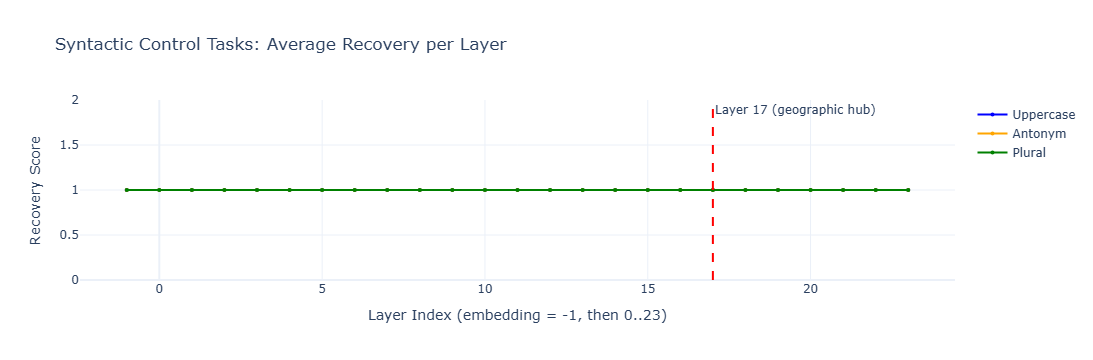

In [1]:
"""
Syntactic Control Experiment: Activation Patching on Simple Tasks
Version with dynamic filtering to ensure single‑token targets.
"""

import torch
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from transformer_lens import HookedTransformer
from tqdm import tqdm

# ------------------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------------------
MODEL_NAME = "Qwen2-0.5B"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

# ------------------------------------------------------------------------------
# Base examples (uppercase and antonyms are fixed, plural is built dynamically)
# ------------------------------------------------------------------------------
BASE_EXAMPLES = [
    # Uppercase mapping (task = "uppercase")
    {"task": "uppercase", "clean": "The letter a is A", "corrupted": "The letter a is B", "pos": "A", "neg": "B"},
    {"task": "uppercase", "clean": "The letter b is B", "corrupted": "The letter b is C", "pos": "B", "neg": "C"},
    {"task": "uppercase", "clean": "The letter c is C", "corrupted": "The letter c is D", "pos": "C", "neg": "D"},
    {"task": "uppercase", "clean": "The letter d is D", "corrupted": "The letter d is E", "pos": "D", "neg": "E"},
    {"task": "uppercase", "clean": "The letter e is E", "corrupted": "The letter e is F", "pos": "E", "neg": "F"},
    {"task": "uppercase", "clean": "The letter f is F", "corrupted": "The letter f is G", "pos": "F", "neg": "G"},
    {"task": "uppercase", "clean": "The letter g is G", "corrupted": "The letter g is H", "pos": "G", "neg": "H"},
    {"task": "uppercase", "clean": "The letter h is H", "corrupted": "The letter h is I", "pos": "H", "neg": "I"},
    {"task": "uppercase", "clean": "The letter i is I", "corrupted": "The letter i is J", "pos": "I", "neg": "J"},
    {"task": "uppercase", "clean": "The letter j is J", "corrupted": "The letter j is K", "pos": "J", "neg": "K"},

    # Antonyms (task = "antonym")
    {"task": "antonym", "clean": "The opposite of hot is cold", "corrupted": "The opposite of hot is hot", "pos": "cold", "neg": "hot"},
    {"task": "antonym", "clean": "The opposite of big is small", "corrupted": "The opposite of big is big", "pos": "small", "neg": "big"},
    {"task": "antonym", "clean": "The opposite of fast is slow", "corrupted": "The opposite of fast is fast", "pos": "slow", "neg": "fast"},
    {"task": "antonym", "clean": "The opposite of happy is sad", "corrupted": "The opposite of happy is happy", "pos": "sad", "neg": "happy"},
    {"task": "antonym", "clean": "The opposite of light is dark", "corrupted": "The opposite of light is light", "pos": "dark", "neg": "light"},
    {"task": "antonym", "clean": "The opposite of rich is poor", "corrupted": "The opposite of rich is rich", "pos": "poor", "neg": "rich"},
    {"task": "antonym", "clean": "The opposite of high is low", "corrupted": "The opposite of high is high", "pos": "low", "neg": "high"},
    {"task": "antonym", "clean": "The opposite of strong is weak", "corrupted": "The opposite of strong is strong", "pos": "weak", "neg": "strong"},
    {"task": "antonym", "clean": "The opposite of young is old", "corrupted": "The opposite of young is young", "pos": "old", "neg": "young"},
    {"task": "antonym", "clean": "The opposite of long is short", "corrupted": "The opposite of long is long", "pos": "short", "neg": "long"},
]

# ------------------------------------------------------------------------------
# Candidate plural pairs – we will test each during runtime
# ------------------------------------------------------------------------------
PLURAL_CANDIDATES = [
    ("cat", "cats"),
    ("dog", "dogs"),
    ("bird", "birds"),
    ("car", "cars"),
    ("house", "houses"),
    ("book", "books"),
    ("tree", "trees"),
    ("flower", "flowers"),
    ("student", "students"),
    ("apple", "apples"),
    ("pear", "pears"),
    ("pen", "pens"),
    ("desk", "desks"),
]

# ------------------------------------------------------------------------------
# Load model and tokenizer (early to test tokenization)
# ------------------------------------------------------------------------------
print(f"Loading {MODEL_NAME} on {DEVICE}...")
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    dtype=DTYPE,
    fold_ln=False,
    center_writing_weights=False
)
tokenizer = model.tokenizer

# ------------------------------------------------------------------------------
# Build plural examples by testing tokenization
# ------------------------------------------------------------------------------
plural_examples = []
for sing, plur in PLURAL_CANDIDATES:
    pos_tok = tokenizer.encode(" " + plur, add_special_tokens=False)   # add space to match prompt pattern
    neg_tok = tokenizer.encode(" " + sing, add_special_tokens=False)
    if len(pos_tok) == 1 and len(neg_tok) == 1:
        # Clean: "One {sing}, two {plur}"
        # Corrupted: "One {sing}, two {sing}" (repeating singular)
        clean = f"One {sing}, two {plur}"
        corrupted = f"One {sing}, two {sing}"
        plural_examples.append({
            "task": "plural",
            "clean": clean,
            "corrupted": corrupted,
            "pos": plur,
            "neg": sing,
        })
        print(f"Plural pair accepted: {sing} -> {plur} (tokens: {neg_tok[0]} / {pos_tok[0]})")
    else:
        print(f"Plural pair rejected: {sing} -> {plur} (tokens: {neg_tok} / {pos_tok})")

# ------------------------------------------------------------------------------
# Combine all examples
# ------------------------------------------------------------------------------
SYNTACTIC_EXAMPLES = BASE_EXAMPLES + plural_examples

# ------------------------------------------------------------------------------
# Verify all targets are single tokens
# ------------------------------------------------------------------------------
for ex in SYNTACTIC_EXAMPLES:
    pos_tok = tokenizer.encode(" " + ex["pos"], add_special_tokens=False)
    neg_tok = tokenizer.encode(" " + ex["neg"], add_special_tokens=False)
    if len(pos_tok) != 1 or len(neg_tok) != 1:
        raise ValueError(f"Targets must be single tokens: {ex['pos']} -> {pos_tok}, {ex['neg']} -> {neg_tok}")
    ex["pos_id"] = pos_tok[0]
    ex["neg_id"] = neg_tok[0]

print(f"\nTotal examples: {len(SYNTACTIC_EXAMPLES)}")
print(f"Uppercase: {len([e for e in SYNTACTIC_EXAMPLES if e['task'] == 'uppercase'])}")
print(f"Antonyms: {len([e for e in SYNTACTIC_EXAMPLES if e['task'] == 'antonym'])}")
print(f"Plural: {len([e for e in SYNTACTIC_EXAMPLES if e['task'] == 'plural'])}")

# ------------------------------------------------------------------------------
# Helper functions (same as before)
# ------------------------------------------------------------------------------
def get_logits_and_cache(prompt: str):
    tokens = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits, cache = model.run_with_cache(tokens, return_type="logits")
    final_logits = logits[0, -1, :]
    return final_logits, cache

def logit_diff(logits, pos_id, neg_id):
    return logits[pos_id] - logits[neg_id]

def patch_and_compute_recovery(clean_prompt, corrupted_prompt, pos_id, neg_id,
                               clean_diff, corrupted_diff, clean_cache):
    n_layers = model.cfg.n_layers
    recovery_scores = []

    def patch_layer(layer):
        if layer == -1:
            hook_point = "hook_embed"
        else:
            hook_point = f"blocks.{layer}.hook_resid_post"

        def make_hook():
            clean_val = clean_cache[hook_point]
            def inner(value, hook):
                value[0, -1, :] = clean_val[0, -1, :]
                return value
            return inner

        tokens = tokenizer.encode(corrupted_prompt, return_tensors="pt").to(DEVICE)
        with model.hooks(fwd_hooks=[(hook_point, make_hook())]):
            with torch.no_grad():
                logits = model(tokens)
        return logits[0, -1, :]

    for layer in range(-1, n_layers):
        patched_logits = patch_layer(layer)
        patched_diff = logit_diff(patched_logits, pos_id, neg_id)
        denom = clean_diff - corrupted_diff
        rec = 0.0 if denom == 0 else (patched_diff - corrupted_diff) / denom
        recovery_scores.append(float(rec))
    return recovery_scores

# ------------------------------------------------------------------------------
# Run experiment per example, accumulate per task
# ------------------------------------------------------------------------------
n_layers = model.cfg.n_layers
layer_names = ["embedding"] + [f"layer_{i}" for i in range(n_layers)]

per_task_recoveries = {}

for ex in SYNTACTIC_EXAMPLES:
    task = ex["task"]
    if task not in per_task_recoveries:
        per_task_recoveries[task] = []

    # Compute clean and corrupted baselines
    clean_logits, clean_cache = get_logits_and_cache(ex["clean"])
    clean_diff = logit_diff(clean_logits, ex["pos_id"], ex["neg_id"])
    corrupted_logits, corrupted_cache = get_logits_and_cache(ex["corrupted"])
    corrupted_diff = logit_diff(corrupted_logits, ex["pos_id"], ex["neg_id"])
    print(f"{task}: '{ex['clean'][:30]}...' clean diff = {clean_diff:.4f}, corrupted diff = {corrupted_diff:.4f}")

    # Run patching
    rec = patch_and_compute_recovery(
        ex["clean"], ex["corrupted"],
        ex["pos_id"], ex["neg_id"],
        clean_diff, corrupted_diff,
        clean_cache
    )
    per_task_recoveries[task].append(rec)

# ------------------------------------------------------------------------------
# Average recovery per task
# ------------------------------------------------------------------------------
avg_recovery = {}
for task, rec_list in per_task_recoveries.items():
    avg_rec = np.mean(rec_list, axis=0)
    avg_recovery[task] = avg_rec

# ------------------------------------------------------------------------------
# Save to CSV
# ------------------------------------------------------------------------------
df = pd.DataFrame({"layer": layer_names})
for task, scores in avg_recovery.items():
    df[task] = scores

output_csv = "syntactic_control_recovery.csv"
df.to_csv(output_csv, index=False)
print(f"\nRecovery scores (averaged per task) saved to {output_csv}")

# ------------------------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------------------------
print("\n===== Summary Statistics =====")
print(df.to_string(float_format="%.4f"))

print("\n--- First layer where average recovery > 0.5 ---")
for task, scores in avg_recovery.items():
    for i, val in enumerate(scores):
        if val > 0.5:
            print(f"{task:12s} -> {layer_names[i]} (value = {val:.4f})")
            break
    else:
        print(f"{task:12s} -> never exceeds 0.5")

print("\n--- Peak recovery layer (max) ---")
for task, scores in avg_recovery.items():
    peak_idx = np.argmax(scores)
    peak_layer = layer_names[peak_idx]
    peak_val = scores[peak_idx]
    print(f"{task:12s} -> peak at {peak_layer:10s} (recovery = {peak_val:.4f})")

# ------------------------------------------------------------------------------
# Plotting
# ------------------------------------------------------------------------------
fig = go.Figure()
x_vals = list(range(-1, n_layers))
colors = {"uppercase": "blue", "plural": "green", "antonym": "orange"}

for task, scores in avg_recovery.items():
    fig.add_trace(go.Scatter(
        x=x_vals,
        y=scores,
        mode="lines+markers",
        name=task.capitalize(),
        line=dict(color=colors[task], width=2),
        marker=dict(size=4)
    ))

# Highlight layer 17 for reference (geographic hub)
fig.add_vline(x=17, line_dash="dash", line_color="red", annotation_text="Layer 17 (geographic hub)")

fig.update_layout(
    title="Syntactic Control Tasks: Average Recovery per Layer",
    xaxis_title="Layer Index (embedding = -1, then 0..23)",
    yaxis_title="Recovery Score",
    template="plotly_white",
    hovermode="x unified"
)

fig.write_html("syntactic_control_recovery.html")
print("\nInteractive plot saved to syntactic_control_recovery.html")
fig.show()